In [1]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import RobustScaler,LabelEncoder,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv('titanic.csv')

In [3]:
df.head()

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,0


In [4]:
x=df.drop(columns='survived')
y=df['survived']

In [5]:
num_cols = x.select_dtypes(include='number').columns
obj_cols = x.select_dtypes(include='object').columns

C:\Users\Admin\AppData\Local\Temp\ipykernel_6736\3959530517.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = x.select_dtypes(include='object').columns


<Axes: >

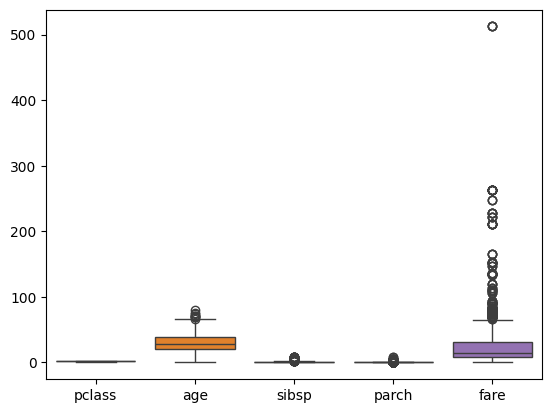

In [6]:
sns.boxplot(x[num_cols])

# train test split

In [7]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,train_size=0.8,random_state=42)

# scaling 

In [8]:
scaling = RobustScaler()

In [9]:
xtrain[num_cols]=scaling.fit_transform(xtrain[num_cols])
xtest[num_cols]=scaling.transform(xtest[num_cols])

#corre

In [10]:
df.corr(numeric_only=True)

,pclass,age,sibsp,parch,fare,survived
pclass,1.000000,-0.408106,0.060832,0.018322,-0.558629,-0.312469
age,-0.408106,1.000000,-0.243699,-0.150917,0.178739,-0.055513
sibsp,0.060832,-0.243699,1.000000,0.373587,0.160238,-0.027825
parch,0.018322,-0.150917,0.373587,1.000000,0.221539,0.082660
fare,-0.558629,0.178739,0.160238,0.221539,1.000000,0.244265
survived,-0.312469,-0.055513,-0.027825,0.082660,0.244265,1.000000


In [11]:
obj_cols

Index(['name', 'sex', 'ticket', 'cabin', 'embarked'], dtype='str')

In [12]:
df.head()

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,0


In [13]:
label_encoder = LabelEncoder()

In [14]:
xtrain['sex'] = label_encoder.fit_transform(xtrain['sex'])
xtrain

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
772,0.0,"Dika, Mr. Mirko",1,-0.624113,0.0,0.0,349232,-0.282835,NaN,S
543,-1.0,"Reeves, Mr. David",1,0.453901,0.0,0.0,C.A. 17248,-0.171306,NaN,S
289,-2.0,"Taussig, Miss. Ruth",0,-0.567376,0.0,2.0,110413,2.790150,E68,S
10,-2.0,"Astor, Col. John Jacob",1,1.078014,1.0,0.0,PC 17757,9.123126,C62 C64,C
147,-2.0,"Harrington, Mr. Charles H",1,NaN,0.0,0.0,113796,1.194861,NaN,S
...,...,...,...,...,...,...,...,...,...,...
1095,0.0,"O'Sullivan, Miss. Bridget Mary",0,NaN,0.0,0.0,330909,-0.294253,NaN,Q
1130,0.0,"Pettersson, Miss. Ellen Natalia",0,-0.567376,0.0,0.0,347087,-0.288009,NaN,S
1294,0.0,"Williams, Mr. Leslie",1,0.028369,0.0,0.0,54636,0.068522,NaN,S
860,0.0,"Heikkinen, Miss. Laina",0,-0.113475,0.0,0.0,STON/O2. 3101282,-0.281585,NaN,S


In [15]:
xtest['sex']= label_encoder.transform(xtest['sex']) 
xtest

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
1148,0.0,"Rintamaki, Mr. Matti",1,0.397163,0.0,0.0,STON/O 2. 3101273,-0.315846,NaN,S
1049,0.0,"Nakid, Mr. Sahid",1,-0.453901,1.0,1.0,2653,0.053178,NaN,C
982,0.0,"Lyntakoff, Mr. Stanko",1,NaN,0.0,0.0,349235,-0.282835,NaN,S
808,0.0,"Ford, Mr. Arthur",1,NaN,0.0,0.0,A/5 1478,-0.276231,NaN,S
1195,0.0,"Shaughnessy, Mr. Patrick",1,NaN,0.0,0.0,370374,-0.289079,NaN,Q
...,...,...,...,...,...,...,...,...,...,...
572,-1.0,"Trout, Mrs. William H (Jessie L)",0,0.000000,0.0,0.0,240929,-0.079229,NaN,S
140,-2.0,"Greenfield, Mr. William Bertram",1,-0.283688,0.0,1.0,PC 17759,2.092433,D10 D12,C
1182,0.0,"Salkjelsvik, Miss. Anna Kristine",0,-0.397163,0.0,0.0,343120,-0.293362,NaN,S
312,-2.0,"Widener, Mr. George Dunton",1,1.248227,1.0,1.0,113503,8.436831,C80,C


In [16]:
xtrain['embarked'] = label_encoder.fit_transform(xtrain['embarked'])
xtrain

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
772,0.0,"Dika, Mr. Mirko",1,-0.624113,0.0,0.0,349232,-0.282835,NaN,2
543,-1.0,"Reeves, Mr. David",1,0.453901,0.0,0.0,C.A. 17248,-0.171306,NaN,2
289,-2.0,"Taussig, Miss. Ruth",0,-0.567376,0.0,2.0,110413,2.790150,E68,2
10,-2.0,"Astor, Col. John Jacob",1,1.078014,1.0,0.0,PC 17757,9.123126,C62 C64,0
147,-2.0,"Harrington, Mr. Charles H",1,NaN,0.0,0.0,113796,1.194861,NaN,2
...,...,...,...,...,...,...,...,...,...,...
1095,0.0,"O'Sullivan, Miss. Bridget Mary",0,NaN,0.0,0.0,330909,-0.294253,NaN,1
1130,0.0,"Pettersson, Miss. Ellen Natalia",0,-0.567376,0.0,0.0,347087,-0.288009,NaN,2
1294,0.0,"Williams, Mr. Leslie",1,0.028369,0.0,0.0,54636,0.068522,NaN,2
860,0.0,"Heikkinen, Miss. Laina",0,-0.113475,0.0,0.0,STON/O2. 3101282,-0.281585,NaN,2


In [17]:
xtest['embarked'] = label_encoder.transform(xtest['embarked'])
xtest

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
1148,0.0,"Rintamaki, Mr. Matti",1,0.397163,0.0,0.0,STON/O 2. 3101273,-0.315846,NaN,2
1049,0.0,"Nakid, Mr. Sahid",1,-0.453901,1.0,1.0,2653,0.053178,NaN,0
982,0.0,"Lyntakoff, Mr. Stanko",1,NaN,0.0,0.0,349235,-0.282835,NaN,2
808,0.0,"Ford, Mr. Arthur",1,NaN,0.0,0.0,A/5 1478,-0.276231,NaN,2
1195,0.0,"Shaughnessy, Mr. Patrick",1,NaN,0.0,0.0,370374,-0.289079,NaN,1
...,...,...,...,...,...,...,...,...,...,...
572,-1.0,"Trout, Mrs. William H (Jessie L)",0,0.000000,0.0,0.0,240929,-0.079229,NaN,2
140,-2.0,"Greenfield, Mr. William Bertram",1,-0.283688,0.0,1.0,PC 17759,2.092433,D10 D12,0
1182,0.0,"Salkjelsvik, Miss. Anna Kristine",0,-0.397163,0.0,0.0,343120,-0.293362,NaN,2
312,-2.0,"Widener, Mr. George Dunton",1,1.248227,1.0,1.0,113503,8.436831,C80,0


In [18]:
print(xtrain.isnull().sum())


pclass        0
name          0
sex           0
age         207
sibsp         0
parch         0
ticket        0
fare          1
cabin       813
embarked      0
dtype: int64


In [19]:
df.drop("cabin",axis=1,inplace=True)
df.drop("name",axis=1,inplace=True)


In [20]:
df.head()

,pclass,sex,age,sibsp,parch,ticket,fare,embarked,survived
0,1,female,29.0000,0,0,24160,211.3375,S,1
1,1,male,0.9167,1,2,113781,151.5500,S,1
2,1,female,2.0000,1,2,113781,151.5500,S,0
3,1,male,30.0000,1,2,113781,151.5500,S,0
4,1,female,25.0000,1,2,113781,151.5500,S,0


In [21]:
xtrain['age']=xtrain['age'].fillna(xtrain['age'].median())
# xtest['age']=xtest['age'].fillna(xtest['age'].median())

In [22]:
# xtrain['embarked']=xtrain['embarked'].fillna(xtrain['embarked'].mode()[0])
# xtest['embarked']=xtest['embarked'].fillna(xtest['embarked'].mode()[0])

In [23]:
model = LinearRegression()
model.fit(xtrain,ytrain)

ValueError: could not convert string to float: 'Dika, Mr. Mirko'